Import Librariesz

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 9.6/9.6 MB 1.5 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 KB 2.4 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


#Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\stcok price\Stock Prices Data Set.csv")

#View Data

In [5]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [6]:
#Check for Data type

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


#Convert Date Column to Datetime

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
#Recheck Data type

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


#Checking for missing value

In [11]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

#Handling Missing Value

In [12]:
df['open'] = df['open'].ffill()
df['high'] = df['high'].ffill()
df['low'] = df['low'].ffill()

In [ ]:
#Recheck for missing value

In [13]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [ ]:
#Select one stock, since the dataset contain many companies.

In [14]:
aapl = df[df['symbol'] == 'AAPL']

#Check

In [15]:
aapl.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


#Set Date as Index

In [16]:
aapl = aapl.set_index('date')

#Check

In [17]:
aapl.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


#Sort by Date

In [18]:
aapl = aapl.sort_index()

#Plot Closing Prices

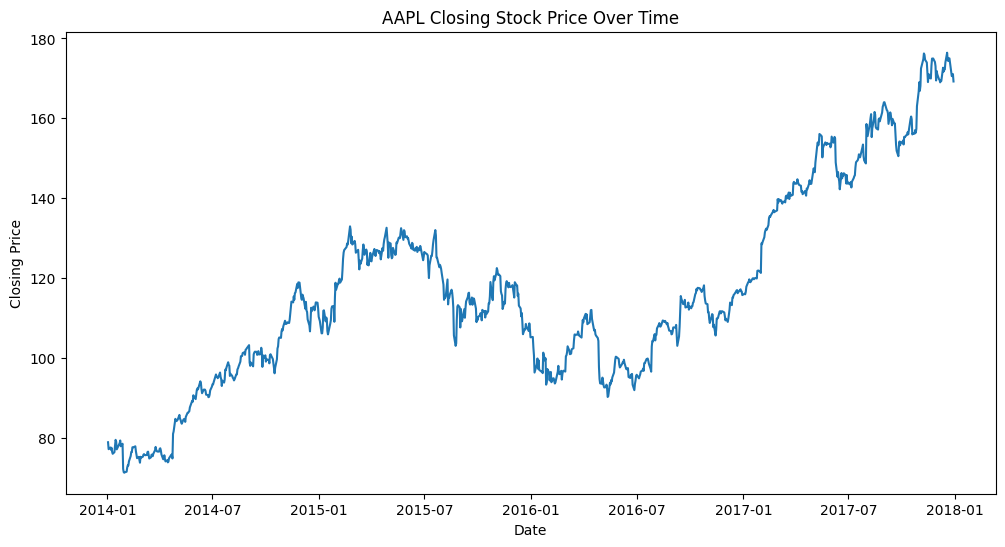

In [19]:
plt.figure(figsize=(12,6))

plt.plot(aapl['close'])

plt.title("AAPL Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

The stock price exhibits an overall upward trend with fluctuations over time. Several peaks and dips indicate periods of increased market activity.

#Check the Time Series

In [20]:
ts = aapl['close']

#Decompose the Time Series

In [21]:
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=252
)

#Plot Decomposition

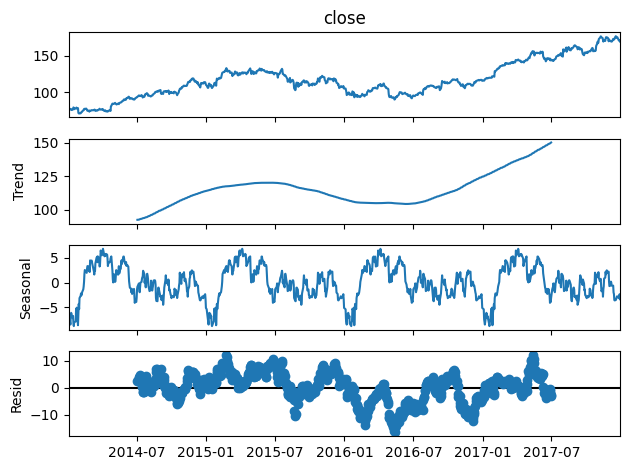

In [22]:
decomposition.plot()

plt.show()

#Trend Component: The trend component shows the long-term movement of stock prices and indicates whether the stock is generally increasing or decreasing over time.

Seasonal Component: The seasonal component captures recurring patterns that occur at regular intervals.

Residual: Residuals represent random fluctuations that are not explained by trend or seasonality.

In [ ]:
#Calculate Moving Average

In [24]:
aapl['MA_30'] = aapl['close'].rolling(window=30).mean()

#Plot Moving Average

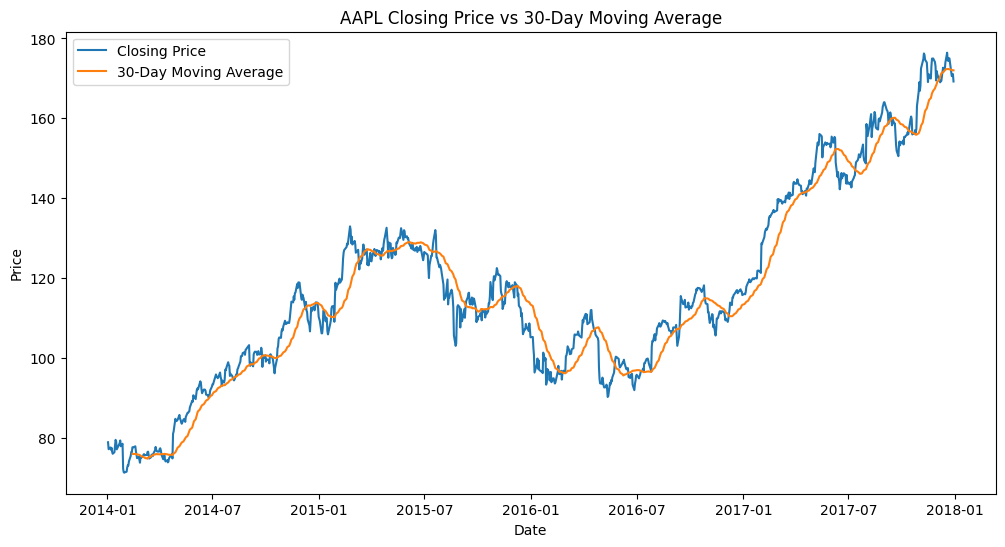

In [25]:
plt.figure(figsize=(12,6))

plt.plot(
    aapl['close'],
    label='Closing Price'
)

plt.plot(
    aapl['MA_30'],
    label='30-Day Moving Average'
)

plt.title("AAPL Closing Price vs 30-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

#The moving average smooths short-term fluctuations and highlights the underlying trend in stock prices. It makes it easier to observe the overall market direction.

#Save Cleaned Dataset

In [26]:
aapl.to_csv("AAPL_TimeSeries.csv")